## Problem 1

Let $f(x) = 2\sin x - \cos{2x}$. Write a function `beauty_derivative_plot` that takes a point $x$ and plots the function $f(x)$ and its derivative $f'(x)$ 
in the range $x \in [-2\pi, 2\pi]$. The function should also plot the tangent line to the function at the point $x$. 

Example of output for $x = -3, -2, 1.7$:

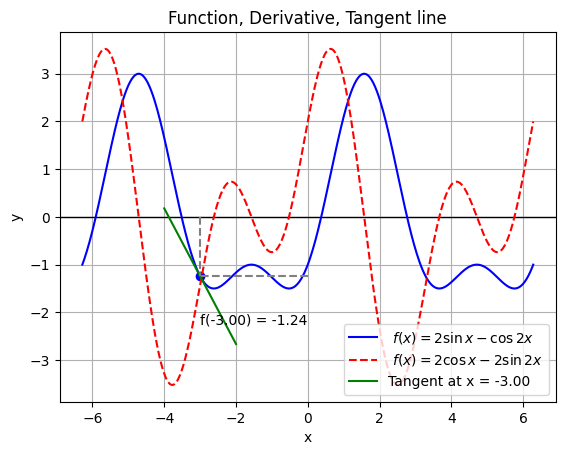

In [2]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
def beauty_derivative_plot(z):
    plt.title("Function, Derivative, Tangent line")
    plt.xlabel('x')
    plt.ylabel('y')
    plt.axhline(0, color='black', linewidth=1)
    px=z
    py=2*np.sin(z)-np.cos(2*z)
    x = np.linspace(-2*np.pi,2*np.pi,500)
    plt.plot(x,2*np.sin(x)-np.cos(2*x),"b-",label =r" $f(x) = 2\sin x - \cos{2x}$")
    plt.plot(px, py, "bo")
    plt.plot(x,2*np.cos(x)+2*np.sin(2*x),"r--",label =r" $f(x) = 2\cos x - 2\sin{2x}$")
    x_tan = np.linspace(z-1, z+1, 500)
    k = 2*np.cos(z)+2*np.sin(2*z)
    b = py-k*z
    plt.plot(x_tan,k*x_tan+b, "g-",label = r"Tangent at x = %0.2f"%px)
    plt.text(px, py-1, "f(%0.2f) = %0.2f"%(px, py),fontsize=10 )
    plt.legend(loc="best")
    plt.plot([z, z], [0, py], linestyle='--', color='gray')
    plt.plot([0, z], [py, py], linestyle='--', color='gray')
    plt.grid(True)
    plt.show()
beauty_derivative_plot(-3)

## Problem 2

The data in [populations.txt](http://www.scipy-lectures.org/_downloads/populations.txt) describes the populations of hares, lynxes and carrots in northern Canada during 20 years. Get the data with 
```python
np.loadtxt('http://www.scipy-lectures.org/_downloads/populations.txt')
```
and do the following exercises **without for-loops (!!!)**.


- Plot the population size of each species for each year on a single graph. Add legend and axis labels to the plot.

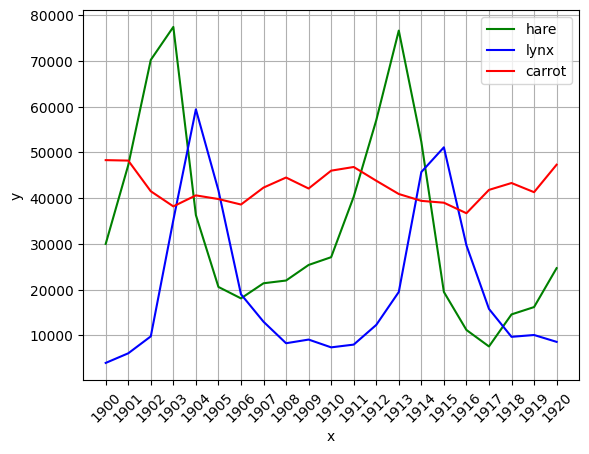

In [65]:
data = np.loadtxt('populations.txt')
col1 = data[:, 0]
col2 = data[:, 1]
col3 = data[:, 2]
col4 = data[:, 3]
plt.plot(col1, col2, "g-", label = "hare")
plt.plot(col1, col3, "b-", label = "lynx")
plt.plot(col1, col4, "r-", label = "carrot")
plt.legend(loc="best")
plt.xlabel('x')
plt.ylabel('y')
plt.xticks(col1, rotation=45)
plt.grid(True)

- Find which year each species had the largest population. Mark these years in the plot of populations.

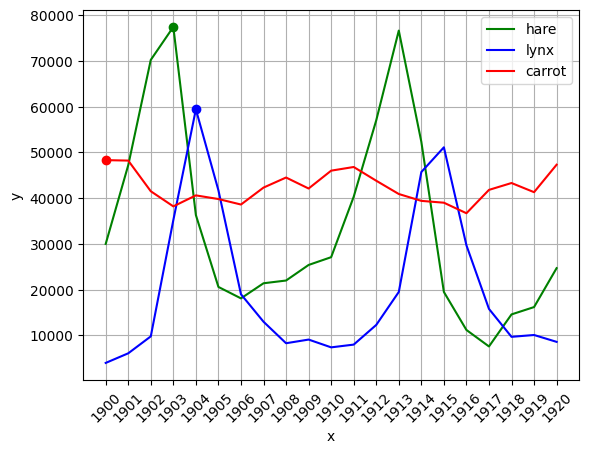

In [80]:
data = np.loadtxt('populations.txt')
col1 = data[:, 0]
col2 = data[:, 1]
col3 = data[:, 2]
col4 = data[:, 3]
plt.plot(col1, col2, "g-", label = "hare")
plt.plot(col1, col3, "b-", label = "lynx")
plt.plot(col1, col4, "r-", label = "carrot")
plt.legend(loc="best")
plt.xlabel('x')
plt.ylabel('y')
plt.xticks(col1, rotation=45)
plt.grid(True)

col2.max()
idx2 = col2.argmax()
plt.plot(col1[idx2], col2[idx2], "go")
col3.max()
idx3 = col3.argmax()
plt.plot(col1[idx3], col3[idx3], "bo")
col4.max()
idx4 = col4.argmax()
plt.plot(col1[idx4], col4[idx4], "ro")

- Assuming total population of hares and lynxes is 100%, plot stacked bar graph showing ratio of each specis for each year in the period.

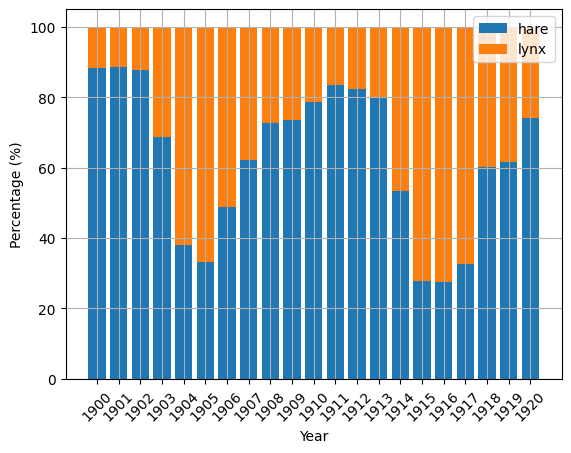

In [93]:
data = np.loadtxt('populations.txt')
col1 = data[:, 0]
col2 = data[:, 1]
col3 = data[:, 2]
col4 = data[:, 3]
total = col2 + col3
hare_ratio = col2 / total * 100
lynx_ratio = col3 / total * 100
plt.bar(col1, hare_ratio, label="hare")
plt.bar(col1, lynx_ratio, bottom=hare_ratio, label="lynx")
plt.grid(True)
plt.legend()
plt.xlabel("Year")
plt.ylabel("Percentage (%)")
plt.xticks(col1, rotation=45)
plt.show()


- Find the mean and std of the populations of each species. Plot the historgam of population for each species and show mean values with vertical line. Show each histogram in a separate plot. Arrange 3 plots in a row.

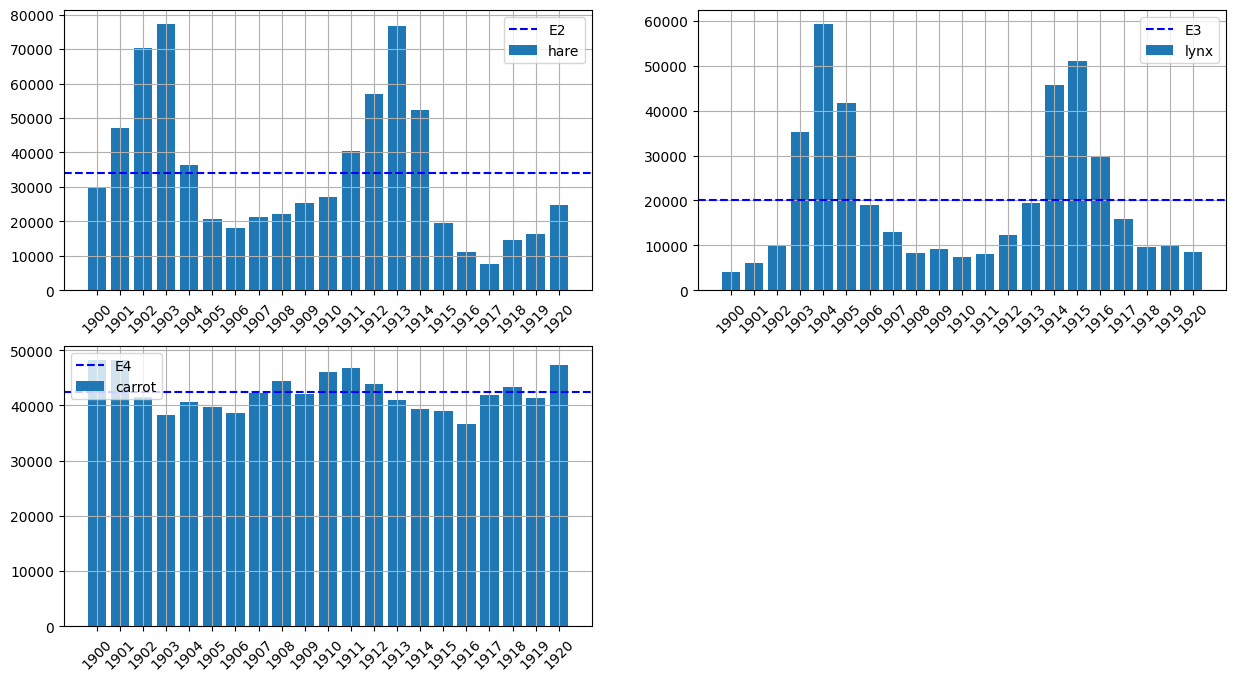

In [116]:
data = np.loadtxt('populations.txt')
col1 = data[:, 0]
col2 = data[:, 1]
col3 = data[:, 2]
col4 = data[:, 3]
E2 = col2.mean()
E3 = col3.mean()
E4 = col4.mean()
D2 = col2.std()
D3 = col3.std()
D4 = col4.std()
plt.figure(figsize=(15, 8))
plt.subplot(2, 2, 1)
plt.bar(col1, col2, label="hare")
plt.grid(True)
plt.xticks(col1, rotation=45)
plt.axhline(E2, linestyle='--', color='b', label = "E2")
plt.legend()
plt.subplot(2, 2, 2)
plt.bar(col1, col3, label="lynx")
plt.xticks(col1, rotation=45)
plt.axhline(E3, linestyle='--', color='b', label = "E3")
plt.grid(True)
plt.legend()
plt.subplot(2, 2, 3)
plt.bar(col1, col4, label="carrot")
plt.xticks(col1, rotation=45)
plt.axhline(E4, linestyle='--', color='b', label = "E4")
plt.grid(True)
plt.legend()
plt.show()


- Find which species (hares or lynxes) has the largest population for each year. Print the result as [H, H, L, H, ...]. Plot a pie chart showing the ratio of "H" and "L" values.

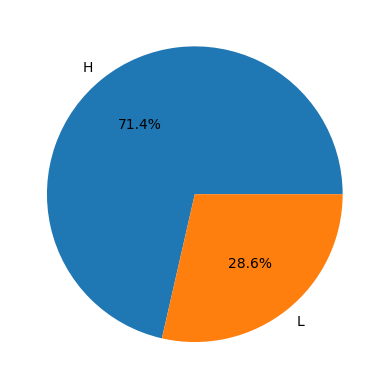

In [125]:
data = np.loadtxt('populations.txt')
col1 = data[:, 0]
col2 = data[:, 1]
col3 = data[:, 2]
col4 = data[:, 3]
mask = col2 > col3
labels = np.where(mask, "H", "L")
H_count = np.sum(labels == "H")
L_count = np.sum(labels == "L")

plt.pie([H_count, L_count], labels=["H", "L"], autopct="%1.1f%%")
plt.show()

- Plot the change in the hare population and in the lynx population for each year. Find the correlation coefficient between the both time series.

-0.17801365941182953


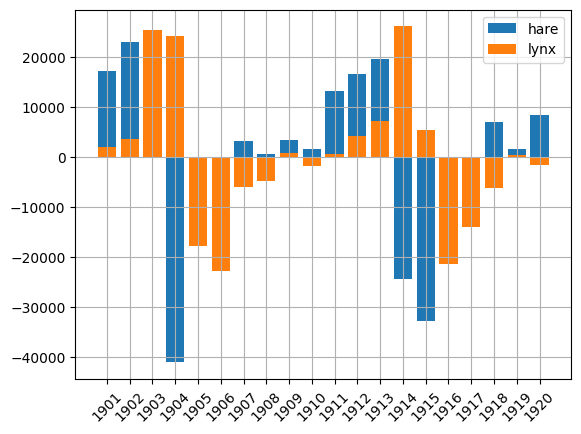

In [58]:
data = np.loadtxt('populations.txt')
col1 = data[:, 0]
col2 = data[:, 1]
col3 = data[:, 2]
col4 = data[:, 3]
col2g = data[1:, 1]
COL2 = col2[1:] - col2[:-1]
COL3 = col3[1:] - col3[:-1]
cov_matrix=np.cov(COL2,COL3)
D2 = COL2.var(ddof=1)
D3 = COL3.var(ddof=1)
cor_matrix= cov_matrix[0,1]/(D2*D3)**0.5
print(cor_matrix)
plt.bar(col1[1:], COL2, label="hare")
plt.bar(col1[1:], COL3, label="lynx")
plt.grid(True)
plt.xticks(col1[1:], rotation=45)
plt.legend()

- Using a scatter plot, show the population of hares vs lynxes by year (each point corresponds to a particular year, and the point coordinates correspond to the population of the two species in that year).

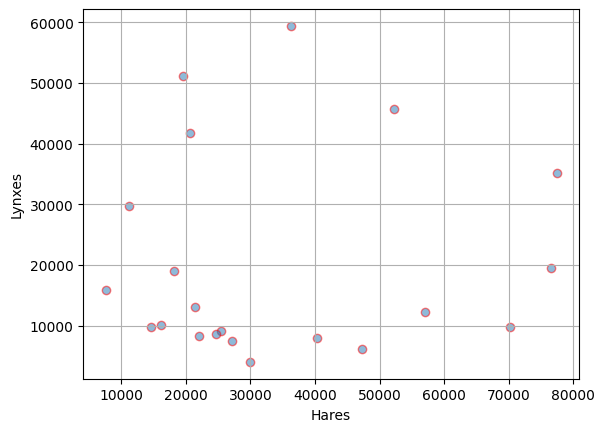

In [65]:
col2 = data[:, 1]
col3 = data[:, 2]
plt.scatter(col2, col3, alpha=0.5, edgecolors='red')
plt.xlabel("Hares")
plt.ylabel("Lynxes")
plt.grid(True)

- Assume the population of hares in 1920 is unknown. Suggest a way to estimate this value. Compare an estimated value
with the true value and print a ratio of the error to the true value.

In [2]:
?


IPython -- An enhanced Interactive Python

IPython offers a fully compatible replacement for the standard Python
interpreter, with convenient shell features, special commands, command
history mechanism and output results caching.

At your system command line, type 'ipython -h' to see the command line
options available. This document only describes interactive features.

GETTING HELP
------------

Within IPython you have various way to access help:

  ?         -> Introduction and overview of IPython's features (this screen).
  object?   -> Details about 'object'.
  object??  -> More detailed, verbose information about 'object'.
  %quickref -> Quick reference of all IPython specific syntax and magics.
  help      -> Access Python's own help system.

If you are in terminal IPython you can quit this screen by pressing `q`.


MAIN FEATURES
-------------

* Access to the standard Python help with object docstrings and the Python
  manuals. Simply type 'help' (no quotes) to invoke it.

* Ma